In [1]:
%cd ..

/home/ai_n_zag@lab.graphicon.ru/tmp/kolobok


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [3]:
from pathlib import Path
from typing import Tuple, Optional, Iterable, Callable, List, Dict
from collections import OrderedDict

import cv2
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.model_selection import train_test_split

import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import (
    swin_s,
    Swin_S_Weights,
    efficientnet_b7,
    EfficientNet_B7_Weights,
    swin_v2_t,
    Swin_V2_T_Weights,
    vit_b_16,
    ViT_B_16_Weights,
    densenet201,
    DenseNet201_Weights,
    googlenet,
    GoogLeNet_Weights,
    convnext_small,
    ConvNeXt_Small_Weights,
    regnet_y_8gf,
    RegNet_Y_8GF_Weights,
)
from torchvision.models.swin_transformer import Permute
from torchvision.io import read_image
from torchvision import transforms
from torchvision.ops import FeaturePyramidNetwork

from tqdm import tqdm

In [4]:
data_root = Path("data/dataset_crop")

df = pd.read_csv(data_root / "thread_depths.csv")
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)

In [5]:
class ThreadDataset(Dataset):
    def __init__(self, data: pd.DataFrame, data_root_dir: str, transform: Optional[nn.Module] = None):
        self.data = data
        self.data_root_dir = Path(data_root_dir)
        self.image_paths = []
        self.labels = []
        for _, row in self.data.iterrows():
            image_path = self.data_root_dir / row["path"]
            if not image_path.exists():
                print(f"Warning: {image_path} does not exist")
                continue
            self.image_paths.append(self.data_root_dir / row["path"])
            self.labels.append(row["label"])

        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, float]:
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        
        image = read_image(str(image_path))
        if self.transform is not None:
            image = self.transform(image)
        return image, label

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


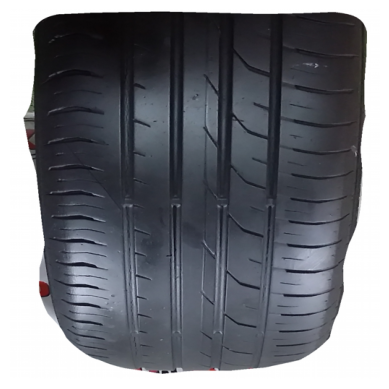

In [6]:
image_path = data_root / df.sample().iloc[0, 0]
img = read_image(image_path)


class Clahe(nn.Module):
    def __init__(self, clip_limit: float = 2.0):
        super().__init__()
        self.clip_limit = clip_limit
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit)

    def _apply_clahe(self, img: np.ndarray) -> np.ndarray:
        result = []
        for channel in img:
            result.append(self.clahe.apply(channel))

        return np.stack(result, axis=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        device = x.device
        x_npy = x.cpu().numpy()
        x_clahe = self._apply_clahe(x_npy)

        return torch.tensor(x_clahe, device=device)


transform = transforms.Compose(
    [
        # Clahe(),
        lambda x: x / 255,
        transforms.Resize(
            (512, 512), interpolation=transforms.InterpolationMode.BICUBIC
        ),
    ]
)

transform_aug = transforms.Compose(
    [
        transform,
        # transforms.ToPILImage(),
        # transforms.RandAugment(
        #     num_ops=3, interpolation=transforms.InterpolationMode.BICUBIC
        # ),
        # transforms.ToTensor(),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        # transforms.RandomAffine(15, (0.05, 0.05), fill=255),
    ]
)

img = transform_aug(img)

plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [7]:
train_dataset = ThreadDataset(df_train, data_root, transform_aug)
val_dataset = ThreadDataset(df_val, data_root, transform)

train_loader = DataLoader(train_dataset, shuffle=True, num_workers=8, batch_size=8)
val_loader = DataLoader(val_dataset, shuffle=False, num_workers=8, batch_size=16)

In [8]:
# model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
# model.fc = nn.Sequential(nn.Linear(2048, 512), nn.ReLU(), nn.Linear(512, 1))

# model = swin_v2_s(weights=Swin_V2_S_Weights.IMAGENET1K_V1)
# model.head = nn.Sequential(nn.Linear(768, 256), nn.ReLU(), nn.Linear(256, 1))

# model = swin_s(weights=Swin_S_Weights.IMAGENET1K_V1)
# model.head = nn.Sequential(nn.Linear(768, 256), nn.ReLU(), nn.Linear(256, 1))

model = efficientnet_b7(weights=EfficientNet_B7_Weights.IMAGENET1K_V1)
model.classifier = nn.Sequential(nn.Linear(2560, 512), nn.SiLU(), nn.Linear(512, 1))

# model = swin_v2_t(weights=Swin_V2_T_Weights.IMAGENET1K_V1)
# model.features[0][0] = nn.Conv2d(in_channels=3, out_channels=96, kernel_size=(5, 5), stride=(2, 2))
# model.head = nn.Sequential(nn.Linear(768, 512), nn.GELU(), nn.Linear(512, 1))

# model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_SWAG_LINEAR_V1)
# model.heads = nn.Sequential(nn.Linear(768, 512), nn.GELU(), nn.Linear(512, 1))

# model = densenet201(weights=DenseNet201_Weights.IMAGENET1K_V1)
# model.classifier = nn.Sequential(nn.Linear(1920, 512), nn.ReLU(), nn.Linear(512, 1))

# model = googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1)
# model.fc = nn.Sequential(nn.Linear(1024, 512), nn.ReLU(), nn.Linear(512, 1))

# model = convnext_small(weights=ConvNeXt_Small_Weights.IMAGENET1K_V1)
# model.classifier[-1] = nn.Sequential(nn.Linear(768, 512), nn.GELU(), nn.Linear(512, 1))

# model = regnet_y_8gf(weights=RegNet_Y_8GF_Weights.IMAGENET1K_V2)
# model.fc = nn.Sequential(nn.Linear(2016, 512), nn.ReLU(), nn.Linear(512, 1))

In [9]:
class SwinFPN(nn.Module):
    def __init__(self):
        super().__init__()

        self.swin = swin_v2_t(weights=Swin_V2_T_Weights.IMAGENET1K_V1).features
        self.fpn = FeaturePyramidNetwork([96, 192, 384, 768], out_channels=64)

        self.resize = transforms.Resize(
            size=(128, 128),
            interpolation=transforms.InterpolationMode.BICUBIC,
        )

        self.head = nn.Sequential(
            self._block(256, 384, 5, 4, 2),  # 128 -> 32
            self._block(384, 512, 5, 4, 2),  # 32 -> 8
            self._block(512, 768, 3, 4, 1),  # 8 -> 2
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Linear(512, 1),
        )

    def _block(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int = 1,
    ) -> nn.Module:
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.GELU(),
            Permute([0, 2, 3, 1]),
            nn.LayerNorm(out_channels),
            Permute([0, 3, 1, 2]),
        )

    def _get_features(self, x: torch.Tensor) -> OrderedDict[int, torch.Tensor]:
        result = OrderedDict()
        for i, module in enumerate(self.swin):
            x = module(x)
            if i % 2 == 1:
                result[len(result)] = x.permute(0, 3, 1, 2)

        return result

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.fpn(self._get_features(x))
        features = {k: self.resize(v) for k, v in features.items()}

        features = torch.cat([map for map in features.values()], dim=1)
        
        return self.head(features)


In [10]:
# model = SwinFPN()

In [11]:
def train_fn(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 10,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.99)

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        running_loss = 0.0
        for images, labels in tqdm(
            train_loader,
            desc=f"Epoch {epoch + 1} Training",
            total=len(train_loader),
        ):
            images = images.to(device)
            labels = labels.to(device, torch.float32).unsqueeze(1)

            
            outputs = model(images).exp()
            loss = criterion(outputs, labels)
            loss.backward()
            
            optimizer.step()
            scheduler.step()

            optimizer.zero_grad()

            running_loss += loss.item()

        print(
            f"Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(train_loader):.4f}"
        )

        model.eval()

        residuals = []
        with torch.no_grad():
            for images, labels in tqdm(
                val_loader, desc=f"Epoch {epoch + 1} Evalutaion"
            ):
                images = images.to(device)
                labels = labels.to(device).unsqueeze(1)

                outputs = model(images).exp()
                residuals.extend(torch.abs(outputs - labels).detach().cpu().tolist())
        residuals = torch.tensor(residuals)
        print(
            f"Validation MAE: {torch.mean(residuals):.4f}, "
            + f"Fraction of errors <= 1: {torch.mean(torch.where(residuals <= 1, 1.0, 0.0))}, "
            + f"0.9th quantile: {torch.quantile(residuals, 0.9)}"
        )

In [ ]:
train_fn(
    model,
    train_loader,
    val_loader,
    num_epochs=30,
)

Epoch 1 Training: 100%|██████████| 145/145 [00:49<00:00,  2.91it/s]


Epoch [1/30], Loss: 7.9047


Epoch 1 Evalutaion: 100%|██████████| 19/19 [00:05<00:00,  3.73it/s]


Validation MAE: 1.2485, Fraction of errors <= 1: 0.4793103337287903, 0.9th quantile: 2.5366549491882324


Epoch 2 Training: 100%|██████████| 145/145 [00:49<00:00,  2.94it/s]


...

Epoch 14 Training: 100%|██████████| 145/145 [00:49<00:00,  2.93it/s]


Epoch [14/30], Loss: 0.6122


Epoch 14 Evalutaion: 100%|██████████| 19/19 [00:04<00:00,  4.11it/s]


Validation MAE: 0.7872, Fraction of errors <= 1: 0.7137930989265442, 0.9th quantile: 1.6885952949523926


Epoch 15 Training:  82%|████████▏ | 119/145 [00:40<00:08,  3.00it/s]

In [ ]:
# # img_path = "/home/ai_n_zag@lab.graphicon.ru/tmp/kolobok/data/threads/thread1.png"
# # img = read_image(img_path).permute(1, 2, 0).numpy()
# # # img = get_thread_crop(img)
# # img = torch.tensor(img).permute(2, 0, 1).to(torch.float32) / 255
# model.eval()
# with torch.no_grad():
#     for img, label in val_loader:
#         pred = model(img.cuda()).exp()
#         print(pred, label)  

tensor([[6.0771]], device='cuda:0') tensor([6.1000], dtype=torch.float64)
tensor([[3.1826]], device='cuda:0') tensor([3.2000], dtype=torch.float64)
tensor([[2.0493]], device='cuda:0') tensor([3.], dtype=torch.float64)
tensor([[6.4794]], device='cuda:0') tensor([6.1000], dtype=torch.float64)
tensor([[0.7433]], device='cuda:0') tensor([1.7000], dtype=torch.float64)
tensor([[5.3466]], device='cuda:0') tensor([7.2000], dtype=torch.float64)
tensor([[8.7228]], device='cuda:0') tensor([8.5000], dtype=torch.float64)
tensor([[5.6025]], device='cuda:0') tensor([7.3000], dtype=torch.float64)
tensor([[7.6769]], device='cuda:0') tensor([8.], dtype=torch.float64)
tensor([[2.0792]], device='cuda:0') tensor([1.4000], dtype=torch.float64)
tensor([[8.3070]], device='cuda:0') tensor([9.], dtype=torch.float64)
tensor([[1.4105]], device='cuda:0') tensor([3.2000], dtype=torch.float64)
tensor([[3.0110]], device='cuda:0') tensor([3.2000], dtype=torch.float64)
tensor([[5.5755]], device='cuda:0') tensor([6.8000